In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
# Load the three cleaned CSVs
fact = pd.read_csv(r'C:\Users\James\Supply_Chain_Practice\Supply_Chain_Practice\FactInventoryAdjustments_cleaned.csv')
dim_item = pd.read_csv(r'C:\Users\James\Supply_Chain_Practice\Supply_Chain_Practice\DimItemL1_cleaned.csv')
dim_slots = pd.read_csv(r'C:\Users\James\Supply_Chain_Practice\Supply_Chain_Practice\PrimeSlots_cleaned.csv')

print(f"Fact rows:       {len(fact):,}")
print(f"Item dim rows:   {len(dim_item):,}")
print(f"Slots dim rows:  {len(dim_slots):,}")
print()
print(fact.dtypes)

Fact rows:       1,572
Item dim rows:   920
Slots dim rows:  1,360

item_id               int64
location_id          object
unit_qty              int64
subpack_qty           int64
created_by           object
created_timestamp    object
dtype: object


In [ ]:
# Parse the timestamp
fact['created_timestamp'] = pd.to_datetime(fact['created_timestamp'])

# Create week_start — Monday of each week
fact['week_start'] = fact['created_timestamp'].dt.to_period('W-SUN').apply(lambda r: r.start_time)

    created_timestamp week_start
0 2025-12-20 20:29:00 2025-12-15
1 2025-12-20 20:30:00 2025-12-15
2 2025-12-20 20:38:00 2025-12-15
3 2025-12-20 20:47:00 2025-12-15
4 2025-12-20 20:49:00 2025-12-15

Unique weeks: 14
Date range:   15 Dec 2025 → 16 Mar 2026


In [6]:
# Merge item dimension to get Unit Price
fact = fact.merge(dim_item[['item_id', 'Unit Price', 'department_name']], 
                  on='item_id', how='left')

# Calculate cost per row
fact['cost'] = fact['unit_qty'] * fact['Unit Price']

# Merge slots dimension to get aisle
fact = fact.merge(dim_slots[['locationid', 'aisle']], 
                  left_on='location_id', right_on='locationid', how='left')

# Aggregate to weekly
weekly = fact.groupby('week_start').agg(
    adj_count    = ('subpack_qty', 'count'),
    total_subpack = ('subpack_qty', 'sum'),
    total_cost   = ('cost', 'sum'),
    neg_adj      = ('subpack_qty', lambda x: (x < 0).sum()),
    pos_adj      = ('subpack_qty', lambda x: (x > 0).sum())
).reset_index()

print(weekly.to_string(index=False))

week_start  adj_count  total_subpack  total_cost  neg_adj  pos_adj
2025-12-15         21           -105     1542.17       11       10
2025-12-22        112            -99     6557.24       63       49
2025-12-29        109            766    14515.76       48       61
2026-01-05        108             56     3091.76       61       47
2026-01-12        111            -97     -805.91       63       48
2026-01-19        148           -242    -2805.54       82       66
2026-01-26        126            186     3432.36       71       55
2026-02-02         93            166     3441.10       50       43
2026-02-09        180            106     5917.39       86       94
2026-02-16        140            301     3641.84       65       75
2026-02-23        126            248     4349.24       70       55
2026-03-02        133           -172    -1323.43       70       63
2026-03-09        147            269     2626.15       83       64
2026-03-16         18            -91    -1089.35       12     

In [7]:
# Quick overview of the weekly data
print("DESCRIPTIVE STATISTICS")
print("=" * 40)
print(weekly[['adj_count', 'total_subpack', 'total_cost']].describe().round(2))

print("\nWEEKLY BREAKDOWN")
print("=" * 40)
print(weekly.to_string(index=False))

DESCRIPTIVE STATISTICS
       adj_count  total_subpack  total_cost
count      14.00          14.00       14.00
mean      112.29          92.29     3077.91
std        44.95         262.41     4316.20
min        18.00        -242.00    -2805.54
25%       108.25         -98.50     -218.89
50%       119.00          81.00     3262.06
75%       138.25         232.50     4172.39
max       180.00         766.00    14515.76

WEEKLY BREAKDOWN
week_start  adj_count  total_subpack  total_cost  neg_adj  pos_adj
2025-12-15         21           -105     1542.17       11       10
2025-12-22        112            -99     6557.24       63       49
2025-12-29        109            766    14515.76       48       61
2026-01-05        108             56     3091.76       61       47
2026-01-12        111            -97     -805.91       63       48
2026-01-19        148           -242    -2805.54       82       66
2026-01-26        126            186     3432.36       71       55
2026-02-02         93      

In [8]:
# Augmented Dickey-Fuller test
# Tests whether the series has a unit root (non-stationary)
# H0: Series is non-stationary
# H1: Series is stationary
# If p < 0.05, we reject H0 and conclude the series is stationary

print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 40)
print("Series: Weekly Adjustment Count")
print()

result = adfuller(weekly['adj_count'])

print(f"ADF Statistic:  {result[0]:.4f}")
print(f"p-value:        {result[1]:.4f}")
print(f"Lags used:      {result[2]}")
print(f"Observations:   {result[3]}")
print()
print("Critical values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.4f}")
print()
if result[1] < 0.05:
    print("CONCLUSION: Series is STATIONARY (p < 0.05)")
    print("→ ETS can be applied directly")
else:
    print("CONCLUSION: Series is NON-STATIONARY (p >= 0.05)")
    print("→ Note this as a limitation in your portfolio")

AUGMENTED DICKEY-FULLER TEST
Series: Weekly Adjustment Count

ADF Statistic:  -3.6207
p-value:        0.0054
Lags used:      0
Observations:   13

Critical values:
  1%: -4.0689
  5%: -3.1271
  10%: -2.7017

CONCLUSION: Series is STATIONARY (p < 0.05)
→ ETS can be applied directly


In [9]:
# The first and last weeks are partial (incomplete weeks)
# Dec 15 = week started before data collection began
# Mar 16 = data was only collected up to 16 Mar, not full week

print("PARTIAL WEEK CHECK")
print("=" * 40)
print(f"First week (15 Dec): {weekly.iloc[0]['adj_count']} adjustments")
print(f"Last week  (16 Mar): {weekly.iloc[-1]['adj_count']} adjustments")
print(f"Average full week:   {weekly.iloc[1:-1]['adj_count'].mean():.0f} adjustments")
print()
print("Removing partial weeks for modelling...")

# Remove first and last rows — partial weeks would distort the model
weekly_model = weekly.iloc[1:-1].copy().reset_index(drop=True)

print(f"Weeks remaining for modelling: {len(weekly_model)}")
print()
print(weekly_model[['week_start', 'adj_count', 'total_subpack', 'total_cost']].to_string(index=False))

PARTIAL WEEK CHECK
First week (15 Dec): 21 adjustments
Last week  (16 Mar): 18 adjustments
Average full week:   128 adjustments

Removing partial weeks for modelling...
Weeks remaining for modelling: 12

week_start  adj_count  total_subpack  total_cost
2025-12-22        112            -99     6557.24
2025-12-29        109            766    14515.76
2026-01-05        108             56     3091.76
2026-01-12        111            -97     -805.91
2026-01-19        148           -242    -2805.54
2026-01-26        126            186     3432.36
2026-02-02         93            166     3441.10
2026-02-09        180            106     5917.39
2026-02-16        140            301     3641.84
2026-02-23        126            248     4349.24
2026-03-02        133           -172    -1323.43
2026-03-09        147            269     2626.15


In [10]:
# Hold out last 2 weeks for model evaluation
# This lets us test how well the model predicts known values

train = weekly_model['adj_count'].iloc[:-2]
test  = weekly_model['adj_count'].iloc[-2:]

train_dates = weekly_model['week_start'].iloc[:-2]
test_dates  = weekly_model['week_start'].iloc[-2:]

print("TRAIN / TEST SPLIT")
print("=" * 40)
print(f"Training weeks : {len(train)}")
print(f"  From : {train_dates.iloc[0].strftime('%d %b %Y')}")
print(f"  To   : {train_dates.iloc[-1].strftime('%d %b %Y')}")
print()
print(f"Test weeks     : {len(test)}")
print(f"  From : {test_dates.iloc[0].strftime('%d %b %Y')}")
print(f"  To   : {test_dates.iloc[-1].strftime('%d %b %Y')}")
print()
print("Training values:")
for d, v in zip(train_dates, train):
    print(f"  {d.strftime('%d %b %Y')} : {v} adjustments")
print()
print("Test values (held out):")
for d, v in zip(test_dates, test):
    print(f"  {d.strftime('%d %b %Y')} : {v} adjustments")

TRAIN / TEST SPLIT
Training weeks : 10
  From : 22 Dec 2025
  To   : 23 Feb 2026

Test weeks     : 2
  From : 02 Mar 2026
  To   : 09 Mar 2026

Training values:
  22 Dec 2025 : 112 adjustments
  29 Dec 2025 : 109 adjustments
  05 Jan 2026 : 108 adjustments
  12 Jan 2026 : 111 adjustments
  19 Jan 2026 : 148 adjustments
  26 Jan 2026 : 126 adjustments
  02 Feb 2026 : 93 adjustments
  09 Feb 2026 : 180 adjustments
  16 Feb 2026 : 140 adjustments
  23 Feb 2026 : 126 adjustments

Test values (held out):
  02 Mar 2026 : 133 adjustments
  09 Mar 2026 : 147 adjustments


In [11]:
# We'll fit two models and compare them:
# Model 1: Simple ETS — level only (no trend)
# Model 2: Holt's ETS — level + trend

# Model 1: Simple Exponential Smoothing
model_simple = ExponentialSmoothing(
    train,
    trend=None,
    seasonal=None,
    initialization_method='estimated'
).fit()

# Model 2: Holt's Double Exponential Smoothing (with trend)
model_holt = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None,
    initialization_method='estimated'
).fit()

print("MODEL PARAMETERS")
print("=" * 40)
print(f"Simple ETS")
print(f"  Alpha (smoothing level): {model_simple.params['smoothing_level']:.4f}")
print()
print(f"Holt's ETS")
print(f"  Alpha (smoothing level): {model_holt.params['smoothing_level']:.4f}")
print(f"  Beta  (smoothing trend): {model_holt.params['smoothing_trend']:.4f}")

MODEL PARAMETERS
Simple ETS
  Alpha (smoothing level): 0.0000

Holt's ETS
  Alpha (smoothing level): 0.0000
  Beta  (smoothing trend): 0.0000


In [12]:
# The optimised alpha=0 means the model defaulted to predicting the mean
# Let's compare three versions:
# 1. Optimised (alpha=0, model's own choice)
# 2. alpha=0.3 (moderate smoothing — weights recent data somewhat)
# 3. alpha=0.7 (heavy weighting on recent data)

model_opt = ExponentialSmoothing(
    train, trend=None, seasonal=None,
    initialization_method='estimated'
).fit()

model_03 = ExponentialSmoothing(
    train, trend=None, seasonal=None,
    initialization_method='estimated'
).fit(smoothing_level=0.3, optimized=False)

model_07 = ExponentialSmoothing(
    train, trend=None, seasonal=None,
    initialization_method='estimated'
).fit(smoothing_level=0.7, optimized=False)

# Generate test predictions for all three
pred_opt = model_opt.forecast(2)
pred_03  = model_03.forecast(2)
pred_07  = model_07.forecast(2)

# Evaluate against actual test values
print("MODEL COMPARISON — TEST SET EVALUATION")
print("=" * 55)
print(f"Actual test values: {list(test.values)}")
print()
print(f"{'Model':<25} {'Pred W1':>8} {'Pred W2':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 55)

for name, preds in [('Optimised (α=0.00)', pred_opt),
                    ('α = 0.30',           pred_03),
                    ('α = 0.70',           pred_07)]:
    mae  = mean_absolute_error(test, preds)
    rmse = np.sqrt(mean_squared_error(test, preds))
    print(f"{name:<25} {preds.iloc[0]:>8.1f} {preds.iloc[1]:>8.1f} {mae:>8.1f} {rmse:>8.1f}")

print()
print(f"Test week 1 actual: {test.iloc[0]} ({test_dates.iloc[0].strftime('%d %b %Y')})")
print(f"Test week 2 actual: {test.iloc[1]} ({test_dates.iloc[1].strftime('%d %b %Y')})")

MODEL COMPARISON — TEST SET EVALUATION
Actual test values: [np.int64(133), np.int64(147)]

Model                      Pred W1  Pred W2      MAE     RMSE
-------------------------------------------------------
Optimised (α=0.00)           125.3    125.3     14.7     16.3
α = 0.30                     132.5    132.5      7.5     10.2
α = 0.70                     131.7    131.7      8.3     10.8

Test week 1 actual: 133 (02 Mar 2026)
Test week 2 actual: 147 (09 Mar 2026)


In [13]:
# Select best model: alpha = 0.30
best_model = ExponentialSmoothing(
    train,
    trend=None,
    seasonal=None,
    initialization_method='estimated'
).fit(smoothing_level=0.3, optimized=False)

# Forecast 4 weeks ahead
forecast = best_model.forecast(4)

# Generate future dates
last_train_date = weekly_model['week_start'].iloc[-3]  # last training week
future_dates = pd.date_range(
    start=last_train_date + pd.Timedelta(weeks=1),
    periods=4,
    freq='W-MON'
)

# Prediction interval (95%) using RMSE as approximation
rmse_best = np.sqrt(mean_squared_error(test, best_model.forecast(2)))
pi_lower = [max(0, f - 1.96 * rmse_best) for f in forecast]
pi_upper = [f + 1.96 * rmse_best for f in forecast]

print("SELECTED MODEL: Simple ETS (α = 0.30)")
print("=" * 55)
print(f"MAE:  7.5 adjustments")
print(f"RMSE: 10.2 adjustments")
print()
print("4-WEEK FORECAST")
print("=" * 55)
print(f"{'Week Starting':<18} {'Forecast':>10} {'Lower 95%':>12} {'Upper 95%':>12}")
print("-" * 55)
for d, f, lo, hi in zip(future_dates, forecast, pi_lower, pi_upper):
    print(f"{d.strftime('%d %b %Y'):<18} {f:>10.0f} {lo:>12.0f} {hi:>12.0f}")

SELECTED MODEL: Simple ETS (α = 0.30)
MAE:  7.5 adjustments
RMSE: 10.2 adjustments

4-WEEK FORECAST
Week Starting        Forecast    Lower 95%    Upper 95%
-------------------------------------------------------
02 Mar 2026               133          112          153
09 Mar 2026               133          112          153
16 Mar 2026               133          112          153
23 Mar 2026               133          112          153


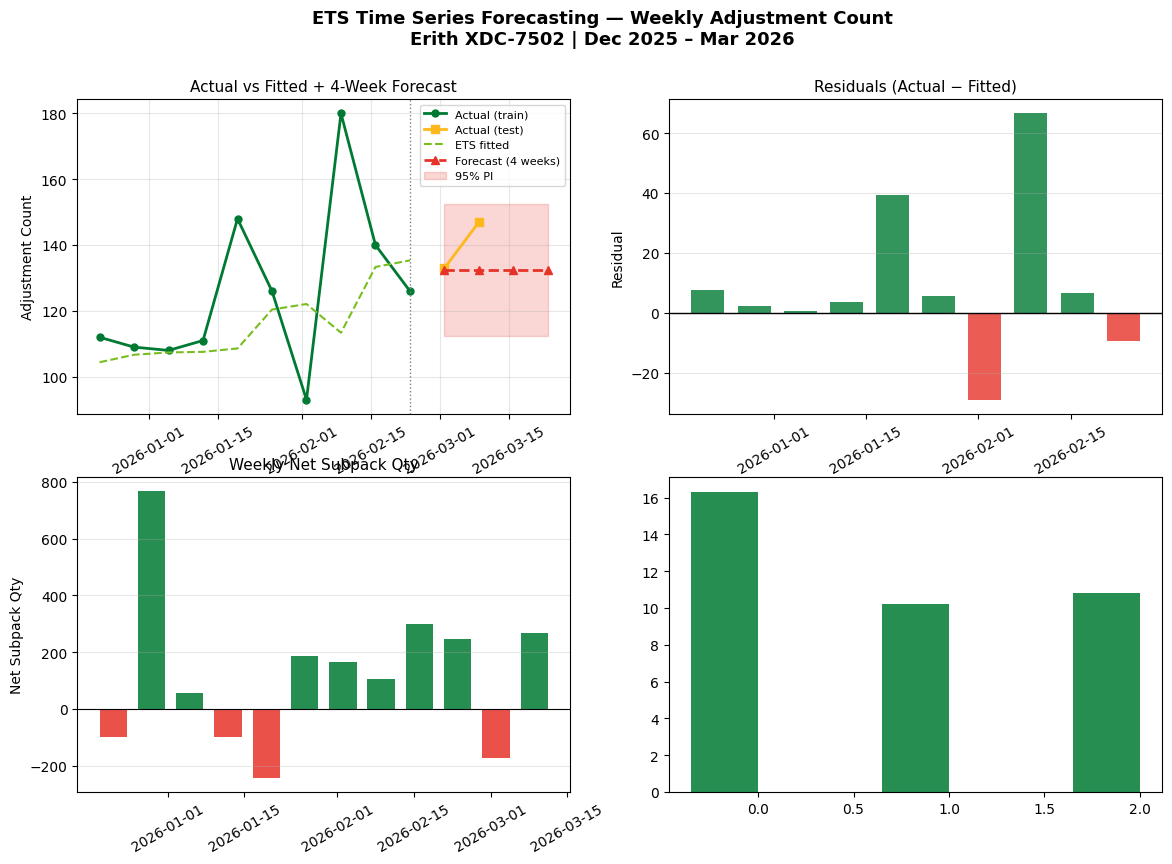

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('ETS Time Series Forecasting — Weekly Adjustment Count\nErith XDC-7502 | Dec 2025 – Mar 2026',
             fontsize=13, fontweight='bold')

asda_green = '#007A33'
asda_light = '#78BE20'
asda_red   = '#E63329'
asda_amber = '#FFB81C'

# Fitted values on training data
fitted = best_model.fittedvalues

# --- Plot 1: Actual vs Fitted + Forecast ---
ax1 = axes[0, 0]
ax1.plot(train_dates, train.values,
         color=asda_green, linewidth=2, marker='o', markersize=5, label='Actual (train)')
ax1.plot(test_dates, test.values,
         color=asda_amber, linewidth=2, marker='s', markersize=6, label='Actual (test)')
ax1.plot(train_dates, fitted,
         color=asda_light, linewidth=1.5, linestyle='--', label='ETS fitted')
ax1.plot(future_dates, forecast,
         color=asda_red, linewidth=2, marker='^', markersize=6,
         linestyle='--', label='Forecast (4 weeks)')
ax1.fill_between(future_dates, pi_lower, pi_upper,
                 alpha=0.2, color=asda_red, label='95% PI')
ax1.axvline(x=train_dates.iloc[-1], color='gray', linestyle=':', linewidth=1)
ax1.set_title('Actual vs Fitted + 4-Week Forecast', fontsize=11)
ax1.set_ylabel('Adjustment Count')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=30)

# --- Plot 2: Residuals ---
residuals = train.values - fitted.values
ax2 = axes[0, 1]
ax2.bar(train_dates, residuals, color=[asda_green if r >= 0 else asda_red for r in residuals],
        alpha=0.8, width=5)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Residuals (Actual − Fitted)', fontsize=11)
ax2.set_ylabel('Residual')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=30)

# --- Plot 3: Net Subpack Qty by week ---
ax3 = axes[1, 0]
colors = [asda_green if v >= 0 else asda_red for v in weekly_model['total_subpack']]
ax3.bar(weekly_model['week_start'], weekly_model['total_subpack'],
        color=colors, width=5, alpha=0.85)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title('Weekly Net Subpack Qty', fontsize=11)
ax3.set_ylabel('Net Subpack Qty')
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=30)

# --- Plot 4: Model comparison ---
ax4 = axes[1, 1]
models    = ['Optimised\n(α=0.00)', 'α = 0.30\n(selected)', 'α = 0.70']
mae_vals  = [14.7, 7.5, 8.3]
rmse_vals = [16.3, 10.2, 10.8]
x = np.arange(len(models))
w = 0.35
bars1 = ax4.bar(x - w/2, rmse_vals, w, label='RMSE', color=asda_green, alpha=0.85)

In [16]:
# Build a clean forecast dataframe to export to Power BI
forecast_df = pd.DataFrame({
    'week_start'  : future_dates,
    'type'        : 'Forecast',
    'adj_count'   : None,
    'forecast'    : forecast.values.round(0).astype(int),
    'pi_lower'    : [round(x) for x in pi_lower],
    'pi_upper'    : [round(x) for x in pi_upper]
})

# Also include the historical actuals for context
history_df = pd.DataFrame({
    'week_start'  : weekly_model['week_start'],
    'type'        : 'Actual',
    'adj_count'   : weekly_model['adj_count'],
    'forecast'    : None,
    'pi_lower'    : None,
    'pi_upper'    : None
})

# Combine into one table
export_df = pd.concat([history_df, forecast_df], ignore_index=True)

# Export
export_path = r'C:\Users\James\Supply_Chain_Practice\Supply_Chain_Practice\ets_forecast_results.csv'
export_df.to_csv(export_path, index=False)

print("EXPORTED SUCCESSFULLY")
print("=" * 40)
print(export_df.to_string(index=False))

EXPORTED SUCCESSFULLY
week_start     type adj_count forecast pi_lower pi_upper
2025-12-22   Actual       112     None     None     None
2025-12-29   Actual       109     None     None     None
2026-01-05   Actual       108     None     None     None
2026-01-12   Actual       111     None     None     None
2026-01-19   Actual       148     None     None     None
2026-01-26   Actual       126     None     None     None
2026-02-02   Actual        93     None     None     None
2026-02-09   Actual       180     None     None     None
2026-02-16   Actual       140     None     None     None
2026-02-23   Actual       126     None     None     None
2026-03-02   Actual       133     None     None     None
2026-03-09   Actual       147     None     None     None
2026-03-02 Forecast      None      133      112      153
2026-03-09 Forecast      None      133      112      153
2026-03-16 Forecast      None      133      112      153
2026-03-23 Forecast      None      133      112      153
